# Phase 2.2 — Memory-Preserving Black Hole Reconstruction U-Net

## Goal

Train a reconstruction model that maps:

```text
noisy / corrupted black-hole observation -> U-Net -> clean black-hole image
```

but with a stronger constraint than the original Phase 2:

```text
reconstruct the clean image without erasing memory-bearing morphology
```

Phase 5.8 deliberately writes physical history into visible morphology. A normal reconstruction model can accidentally smooth away exactly the details Phase 4 needs. So Phase 2.2 uses a memory-preserving reconstruction objective:

```text
pixel L1 loss
+ Sobel edge loss
+ Laplacian high-frequency loss
+ radial profile loss
+ flux conservation loss
```

This notebook trains on:

```text
/home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
```

and saves the checkpoint expected by the next phases:

```text
/home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase510.pt
```

After this notebook finishes, update Phase 4, Phase 4.5, and Phase 5.9 to use that checkpoint.

## 1. Imports and setup

In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

try:
    from skimage.metrics import structural_similarity as ssim
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    print("skimage not available; SSIM metric will be skipped.")

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.9.0+cu128
CUDA available: True


device(type='cuda')

## 2. Configuration

This is the only cell you should normally edit.

In [2]:
PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_phase5_8_morphology"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PHASE22_DIR = OUTPUT_DIR / "phase2_2_memory_preserving_reconstruction_phase510"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PHASE22_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
BATCH_SIZE = 16
NUM_EPOCHS = 40
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 8
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
NUM_WORKERS = 2

IMAGE_SIZE = 128
HISTORY_T = 100

# This is the checkpoint Phase 4 / Phase 4.5 / Phase 5.9 should use next.
BEST_MODEL_PATH = OUTPUT_DIR / "best_unet_memory_preserving_phase510.pt"

# Loss weights. These are intentionally conservative: preserve detail without hallucinating structure.
PIXEL_L1_WEIGHT = 1.00
EDGE_LOSS_WEIGHT = 0.35
LAPLACIAN_LOSS_WEIGHT = 0.25
RADIAL_PROFILE_WEIGHT = 0.10
FLUX_LOSS_WEIGHT = 0.05

TARGET_COLUMNS = [
    "accretion_rate",
    "disk_luminosity",
    "turbulence_level",
    "instability_index",
    "jet_power",
    "spin_evolution",
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

print("Dataset dir:", DATASET_DIR.resolve())
print("Output dir:", OUTPUT_DIR.resolve())
print("Phase 2.2 output dir:", PHASE22_DIR.resolve())
print("Best model path:", BEST_MODEL_PATH.resolve())

Dataset dir: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
Output dir: /home/marwa/files/phase1_blackhole_generator/outputs
Phase 2.2 output dir: /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510
Best model path: /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase510.pt


## 3. Check dataset files

In [3]:
manifest_path = DATASET_DIR / "manifest.json"
params_path = DATASET_DIR / "params_table.csv"

assert DATASET_DIR.exists(), f"Missing dataset directory: {DATASET_DIR}"
assert manifest_path.exists(), f"Missing manifest: {manifest_path}"
assert params_path.exists(), f"Missing params table: {params_path}"
assert (DATASET_DIR / "clean").exists(), f"Missing clean folder: {DATASET_DIR / 'clean'}"
assert (DATASET_DIR / "noisy").exists(), f"Missing noisy folder: {DATASET_DIR / 'noisy'}"
assert (DATASET_DIR / "history").exists(), f"Missing history folder: {DATASET_DIR / 'history'}"

with open(manifest_path, "r") as f:
    manifest = json.load(f)

params_df = pd.read_csv(params_path)

print(json.dumps(manifest, indent=2))
print(params_df.head())
print("Samples:", len(params_df))

{
  "dataset_name": "phase5_8_explicit_morphology_black_hole_memory_dataset",
  "version": "5.8",
  "n_samples": 1000,
  "image_size": 128,
  "seed": 42,
  "save_history": true,
  "history_T": 100,
  "history_conditioned": true,
  "target_columns": [
    "accretion_rate",
    "disk_luminosity",
    "turbulence_level",
    "instability_index",
    "jet_power",
    "spin_evolution"
  ],
  "image_format": "grayscale_png",
  "pixel_range": [
    0.0,
    1.0
  ],
  "source_dataset": "/home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_7_decoupled",
  "output_dataset": "/home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology",
  "filename_pattern": {
    "clean": "clean/bh_XXXX.png",
    "noisy": "noisy/bh_XXXX_noisy.png",
    "metadata": "metadata/bh_XXXX.json",
    "history": "history/bh_XXXX.csv"
  },
  "phase5_8_coupling_description": {
    "accretion_rate": "recent accretion controls compact inner hot-zone radius and intensity",
    "disk_luminosity":

## 4. Dataset class

Each sample returns noisy image, clean image, a compact final/recent physics summary, and sample id.
The physics summary is not used as a supervised predictor here; it is saved for diagnostics and future auditing.

In [4]:
class BlackHoleReconstructionDataset(Dataset):
    def __init__(self, dataset_dir, target_columns=None, history_T=100):
        self.dataset_dir = Path(dataset_dir)
        self.clean_dir = self.dataset_dir / "clean"
        self.noisy_dir = self.dataset_dir / "noisy"
        self.history_dir = self.dataset_dir / "history"
        self.params = pd.read_csv(self.dataset_dir / "params_table.csv")
        self.target_columns = list(target_columns or [])
        self.history_T = history_T

        if "sample_id" not in self.params.columns:
            self.params["sample_id"] = [
                f"bh_{i:04d}" for i in range(1, len(self.params) + 1)
            ]

        self.sample_ids = self.params["sample_id"].tolist()

    def __len__(self):
        return len(self.sample_ids)

    def _load_image(self, path):
        image = Image.open(path).convert("L")
        arr = np.asarray(image, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)

    def _load_history_summary(self, sample_id):
        history_path = self.history_dir / f"{sample_id}.csv"
        df = pd.read_csv(history_path)

        summary = []
        for col in self.target_columns:
            if col not in df.columns:
                raise ValueError(f"Missing {col} in {history_path}")
            y = df[col].to_numpy(dtype=np.float32)
            summary.extend([
                float(y[-1]),
                float(y[-15:].mean()),
                float(y.mean()),
                float(y.std()),
            ])

        return torch.tensor(summary, dtype=torch.float32)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]

        clean_path = self.clean_dir / f"{sample_id}.png"
        noisy_path = self.noisy_dir / f"{sample_id}_noisy.png"

        clean = self._load_image(clean_path)
        noisy = self._load_image(noisy_path)
        history_summary = self._load_history_summary(sample_id)

        return noisy, clean, history_summary, sample_id


dataset = BlackHoleReconstructionDataset(
    DATASET_DIR,
    target_columns=TARGET_COLUMNS,
    history_T=HISTORY_T,
)

print("Dataset size:", len(dataset))
noisy, clean, history_summary, sid = dataset[0]
print("Sample:", sid)
print("Noisy:", noisy.shape, noisy.min().item(), noisy.max().item())
print("Clean:", clean.shape, clean.min().item(), clean.max().item())
print("History summary shape:", history_summary.shape)

Dataset size: 1000
Sample: bh_0001
Noisy: torch.Size([1, 128, 128]) 0.0 1.0
Clean: torch.Size([1, 128, 128]) 0.0 1.0
History summary shape: torch.Size([24])


## 5. Visualize sample pairs

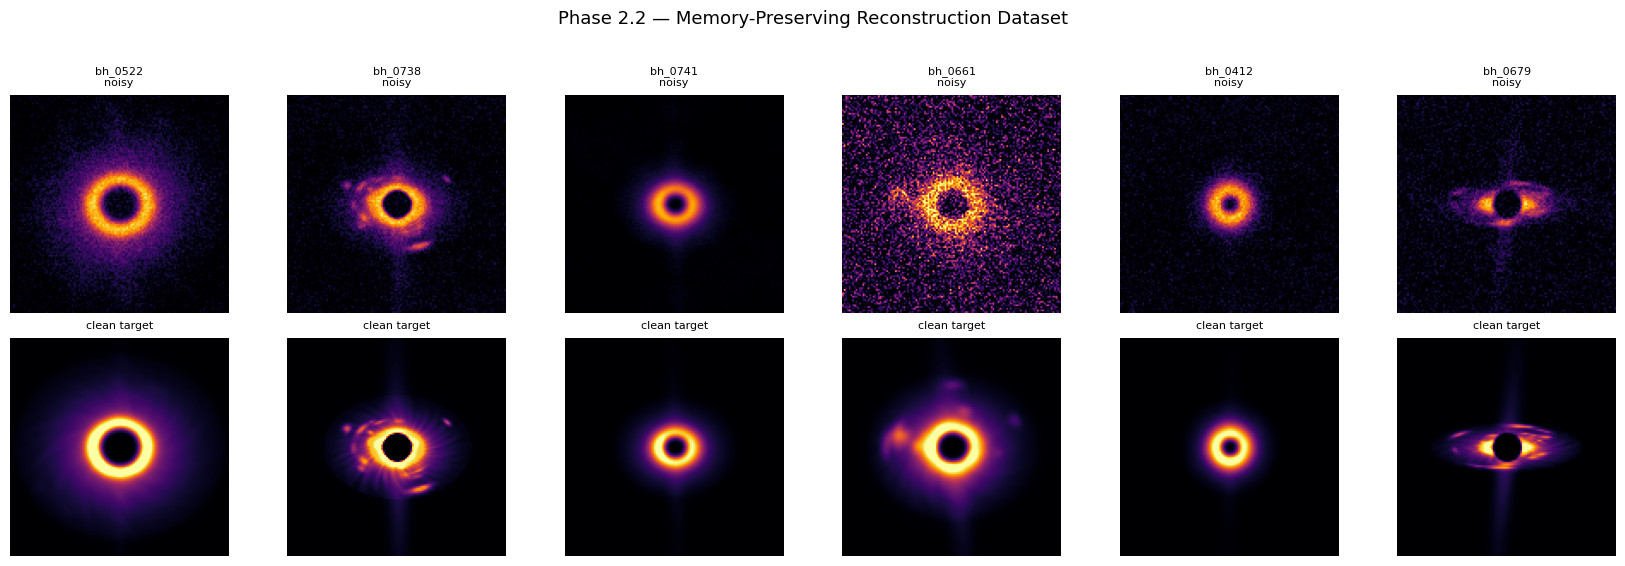

In [5]:
def show_pairs(dataset, n=6):
    indices = np.random.choice(len(dataset), size=n, replace=False)

    fig, axes = plt.subplots(2, n, figsize=(2.8 * n, 5.5))
    if n == 1:
        axes = np.expand_dims(axes, axis=1)

    for col, idx in enumerate(indices):
        noisy, clean, _, sid = dataset[idx]

        axes[0, col].imshow(noisy.squeeze().numpy(), cmap="inferno", vmin=0, vmax=1)
        axes[0, col].set_title(f"{sid}\nnoisy", fontsize=8)
        axes[0, col].axis("off")

        axes[1, col].imshow(clean.squeeze().numpy(), cmap="inferno", vmin=0, vmax=1)
        axes[1, col].set_title("clean target", fontsize=8)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Noisy", fontsize=10)
    axes[1, 0].set_ylabel("Clean", fontsize=10)
    plt.suptitle("Phase 2.2 — Memory-Preserving Reconstruction Dataset", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

show_pairs(dataset, n=6)

## 6. Train / validation / test split

In [6]:
n_total = len(dataset)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=generator,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 800
Val: 100
Test: 100


## 7. U-Net model

This architecture intentionally matches the Phase 4 `SmallUNet` definition. The checkpoint can therefore be loaded directly by Phase 4 and Phase 4.5.

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, out_channels, kernel_size=1)

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return b

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.out(d1))


model = SmallUNet(in_channels=1, out_channels=1, base=32).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable U-Net parameters: {num_params:,}")

Trainable U-Net parameters: 7,762,465


## 8. Memory-preserving losses and metrics

In [8]:
def sobel_kernels(device):
    kx = torch.tensor(
        [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
        dtype=torch.float32,
        device=device,
    ).view(1, 1, 3, 3) / 8.0
    ky = torch.tensor(
        [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
        dtype=torch.float32,
        device=device,
    ).view(1, 1, 3, 3) / 8.0
    return kx, ky


def laplacian_kernel(device):
    return torch.tensor(
        [[0, 1, 0], [1, -4, 1], [0, 1, 0]],
        dtype=torch.float32,
        device=device,
    ).view(1, 1, 3, 3)


def sobel_edges(x):
    kx, ky = sobel_kernels(x.device)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    return torch.sqrt(gx * gx + gy * gy + 1e-8)


def laplacian_response(x):
    k = laplacian_kernel(x.device)
    return F.conv2d(x, k, padding=1)


def radial_profile_tensor(x, num_bins=32):
    # x: [B, 1, H, W]
    B, C, H, W = x.shape
    yy, xx = torch.meshgrid(
        torch.linspace(-1.0, 1.0, H, device=x.device),
        torch.linspace(-1.0, 1.0, W, device=x.device),
        indexing="ij",
    )
    r = torch.sqrt(xx * xx + yy * yy)
    r = torch.clamp(r, 0.0, 1.0)

    profiles = []
    for i in range(num_bins):
        lo = i / num_bins
        hi = (i + 1) / num_bins
        mask = ((r >= lo) & (r < hi)).float().view(1, 1, H, W)
        denom = mask.sum().clamp_min(1.0)
        profiles.append((x * mask).sum(dim=(2, 3)) / denom)

    return torch.stack(profiles, dim=-1)  # [B, 1, num_bins]


def reconstruction_metrics(pred, target):
    mse = F.mse_loss(pred, target).item()
    mae = F.l1_loss(pred, target).item()
    psnr = 99.0 if mse <= 1e-12 else 10.0 * math.log10(1.0 / mse)

    result = {"mse": mse, "mae": mae, "psnr": psnr}

    if HAS_SKIMAGE:
        pred_np = pred.detach().cpu().numpy()
        target_np = target.detach().cpu().numpy()
        scores = []
        for i in range(pred_np.shape[0]):
            scores.append(ssim(target_np[i, 0], pred_np[i, 0], data_range=1.0))
        result["ssim"] = float(np.mean(scores))
    else:
        result["ssim"] = float("nan")

    return result


criterion = nn.L1Loss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=4,
)


def compute_memory_preserving_loss(pred, clean):
    pixel_l1 = criterion(pred, clean)
    edge_l1 = F.l1_loss(sobel_edges(pred), sobel_edges(clean))
    lap_l1 = F.l1_loss(laplacian_response(pred), laplacian_response(clean))
    radial_l1 = F.l1_loss(radial_profile_tensor(pred), radial_profile_tensor(clean))
    flux_l1 = F.l1_loss(pred.mean(dim=(2, 3)), clean.mean(dim=(2, 3)))

    total = (
        PIXEL_L1_WEIGHT * pixel_l1
        + EDGE_LOSS_WEIGHT * edge_l1
        + LAPLACIAN_LOSS_WEIGHT * lap_l1
        + RADIAL_PROFILE_WEIGHT * radial_l1
        + FLUX_LOSS_WEIGHT * flux_l1
    )

    return total, {
        "pixel_l1": pixel_l1,
        "edge_l1": edge_l1,
        "laplacian_l1": lap_l1,
        "radial_l1": radial_l1,
        "flux_l1": flux_l1,
    }

print("Loss weights:")
print("  pixel L1:", PIXEL_L1_WEIGHT)
print("  edge:", EDGE_LOSS_WEIGHT)
print("  laplacian:", LAPLACIAN_LOSS_WEIGHT)
print("  radial profile:", RADIAL_PROFILE_WEIGHT)
print("  flux:", FLUX_LOSS_WEIGHT)

Loss weights:
  pixel L1: 1.0
  edge: 0.35
  laplacian: 0.25
  radial profile: 0.1
  flux: 0.05


## 9. Training and evaluation functions

In [9]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0

    component_sums = {
        "pixel_l1": 0.0,
        "edge_l1": 0.0,
        "laplacian_l1": 0.0,
        "radial_l1": 0.0,
        "flux_l1": 0.0,
    }

    for noisy, clean, _, _ in loader:
        noisy = noisy.to(DEVICE, non_blocking=True)
        clean = clean.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(noisy)

        loss, components = compute_memory_preserving_loss(pred, clean)
        loss.backward()
        optimizer.step()

        batch_size = noisy.size(0)
        running_loss += loss.item() * batch_size
        for key in component_sums:
            component_sums[key] += components[key].item() * batch_size

    out = {"loss": running_loss / len(loader.dataset)}
    for key, value in component_sums.items():
        out[key] = value / len(loader.dataset)
    return out


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    losses = []
    pixel_l1s = []
    edge_l1s = []
    lap_l1s = []
    radial_l1s = []
    flux_l1s = []
    mses = []
    maes = []
    psnrs = []
    ssims = []

    for noisy, clean, _, _ in loader:
        noisy = noisy.to(DEVICE, non_blocking=True)
        clean = clean.to(DEVICE, non_blocking=True)

        pred = model(noisy)
        loss, components = compute_memory_preserving_loss(pred, clean)
        metrics = reconstruction_metrics(pred, clean)

        losses.append(loss.item())
        pixel_l1s.append(components["pixel_l1"].item())
        edge_l1s.append(components["edge_l1"].item())
        lap_l1s.append(components["laplacian_l1"].item())
        radial_l1s.append(components["radial_l1"].item())
        flux_l1s.append(components["flux_l1"].item())
        mses.append(metrics["mse"])
        maes.append(metrics["mae"])
        psnrs.append(metrics["psnr"])
        ssims.append(metrics["ssim"])

    return {
        "loss": float(np.mean(losses)),
        "pixel_l1": float(np.mean(pixel_l1s)),
        "edge_l1": float(np.mean(edge_l1s)),
        "laplacian_l1": float(np.mean(lap_l1s)),
        "radial_l1": float(np.mean(radial_l1s)),
        "flux_l1": float(np.mean(flux_l1s)),
        "mse": float(np.mean(mses)),
        "mae": float(np.mean(maes)),
        "psnr": float(np.mean(psnrs)),
        "ssim": float(np.mean(ssims)),
    }

## 10. Train memory-preserving U-Net

In [10]:
best_val_loss = float("inf")
patience_counter = 0
history = []

print("\n====================================================")
print("Phase 2.2 — Memory-Preserving Reconstruction Training")
print("====================================================")
print(f"Dataset          : {DATASET_DIR}")
print(f"Checkpoint path  : {BEST_MODEL_PATH}")
print("====================================================\n")

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer)
    val_metrics = evaluate(model, val_loader)

    scheduler.step(val_metrics["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_pixel_l1": train_metrics["pixel_l1"],
        "train_edge_l1": train_metrics["edge_l1"],
        "train_laplacian_l1": train_metrics["laplacian_l1"],
        "train_radial_l1": train_metrics["radial_l1"],
        "train_flux_l1": train_metrics["flux_l1"],
        "val_loss": val_metrics["loss"],
        "val_pixel_l1": val_metrics["pixel_l1"],
        "val_edge_l1": val_metrics["edge_l1"],
        "val_laplacian_l1": val_metrics["laplacian_l1"],
        "val_radial_l1": val_metrics["radial_l1"],
        "val_flux_l1": val_metrics["flux_l1"],
        "val_mse": val_metrics["mse"],
        "val_mae": val_metrics["mae"],
        "val_psnr": val_metrics["psnr"],
        "val_ssim": val_metrics["ssim"],
        "lr": current_lr,
    }
    history.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_loss": best_val_loss,
                "dataset_dir": str(DATASET_DIR),
                "architecture": "SmallUNet",
                "base_channels": 32,
                "image_size": IMAGE_SIZE,
                "phase": "2.2_memory_preserving_reconstruction",
                "loss_weights": {
                    "pixel_l1": PIXEL_L1_WEIGHT,
                    "edge": EDGE_LOSS_WEIGHT,
                    "laplacian": LAPLACIAN_LOSS_WEIGHT,
                    "radial_profile": RADIAL_PROFILE_WEIGHT,
                    "flux": FLUX_LOSS_WEIGHT,
                },
                "config": {
                    "seed": SEED,
                    "batch_size": BATCH_SIZE,
                    "num_epochs": NUM_EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                    "train_ratio": TRAIN_RATIO,
                    "val_ratio": VAL_RATIO,
                    "test_ratio": TEST_RATIO,
                },
            },
            BEST_MODEL_PATH,
        )
        best_flag = " <-- best"
    else:
        patience_counter += 1
        best_flag = ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"train={train_metrics['loss']:.5f} | "
        f"val={val_metrics['loss']:.5f} | "
        f"pix={val_metrics['pixel_l1']:.5f} | "
        f"edge={val_metrics['edge_l1']:.5f} | "
        f"lap={val_metrics['laplacian_l1']:.5f} | "
        f"PSNR={val_metrics['psnr']:.2f} | "
        f"SSIM={val_metrics['ssim']:.3f} | "
        f"lr={current_lr:.2e}"
        f"{best_flag}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        print(f"Best validation loss: {best_val_loss:.5f}")
        break

history_df = pd.DataFrame(history)
history_csv_path = PHASE22_DIR / "phase2_2_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

best_epoch_idx = history_df["val_loss"].idxmin()

print("\n====================================================")
print("Training complete")
print("====================================================")
print(f"Best epoch       : {history_df.loc[best_epoch_idx, 'epoch']}")
print(f"Best val loss    : {history_df.loc[best_epoch_idx, 'val_loss']:.5f}")
print(f"Best val pixel   : {history_df.loc[best_epoch_idx, 'val_pixel_l1']:.5f}")
print(f"Best val edge    : {history_df.loc[best_epoch_idx, 'val_edge_l1']:.5f}")
print(f"Best val lap     : {history_df.loc[best_epoch_idx, 'val_laplacian_l1']:.5f}")
print(f"Best PSNR        : {history_df.loc[best_epoch_idx, 'val_psnr']:.2f}")
print(f"Best SSIM        : {history_df.loc[best_epoch_idx, 'val_ssim']:.4f}")
print("\nSaved files:")
print(" ", BEST_MODEL_PATH)
print(" ", history_csv_path)
print("====================================================")


Phase 2.2 — Memory-Preserving Reconstruction Training
Dataset          : /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology
Checkpoint path  : /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase510.pt

Epoch 001/40 | train=0.37561 | val=0.32866 | pix=0.27255 | edge=0.01957 | lap=0.03129 | PSNR=10.55 | SSIM=0.139 | lr=1.00e-03 <-- best
Epoch 002/40 | train=0.23673 | val=0.20975 | pix=0.17826 | edge=0.01038 | lap=0.01717 | PSNR=14.00 | SSIM=0.238 | lr=1.00e-03 <-- best
Epoch 003/40 | train=0.15759 | val=0.11560 | pix=0.09651 | edge=0.00758 | lap=0.01276 | PSNR=19.49 | SSIM=0.303 | lr=1.00e-03 <-- best
Epoch 004/40 | train=0.09500 | val=0.07274 | pix=0.05968 | edge=0.00612 | lap=0.01138 | PSNR=23.73 | SSIM=0.363 | lr=1.00e-03 <-- best
Epoch 005/40 | train=0.05905 | val=0.04783 | pix=0.03893 | edge=0.00507 | lap=0.00949 | PSNR=27.08 | SSIM=0.418 | lr=1.00e-03 <-- best
Epoch 006/40 | train=0.04256 | val=0.03537 | pix=0.02754 | e

## 11. Plot training curves

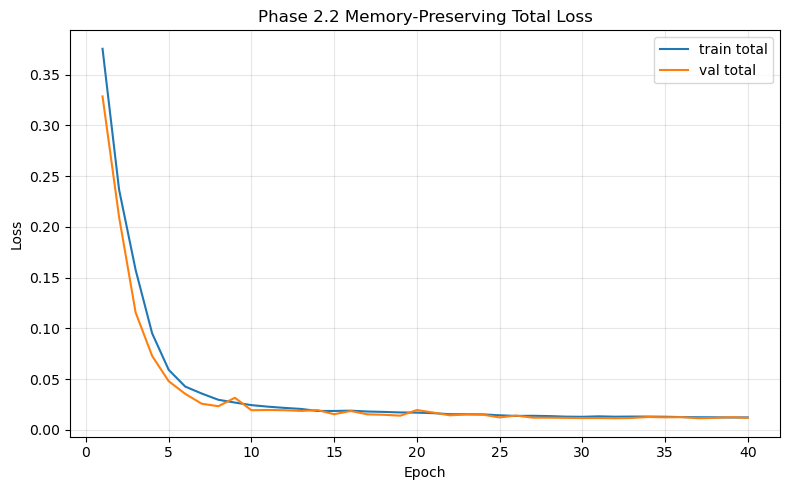

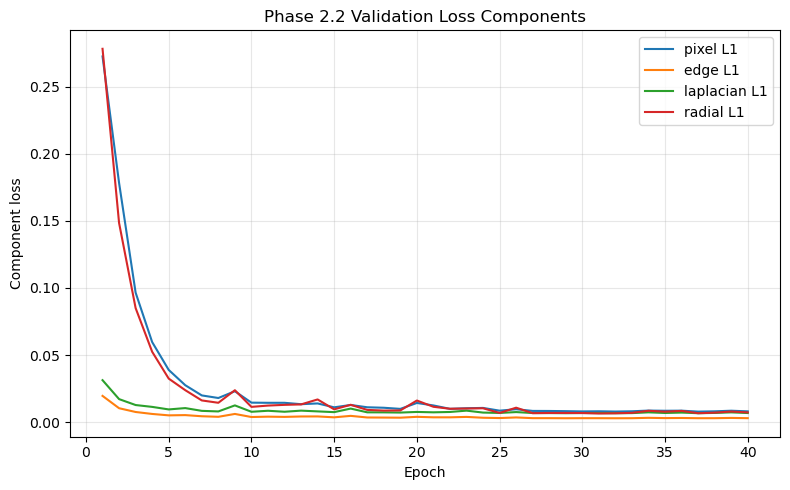

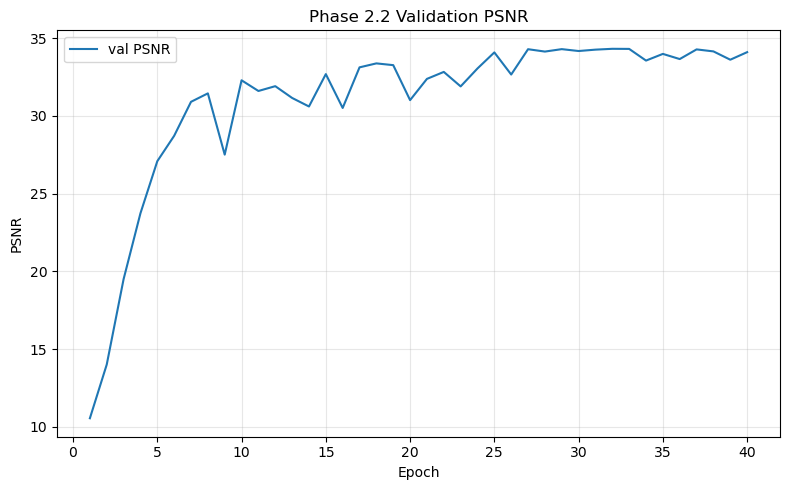

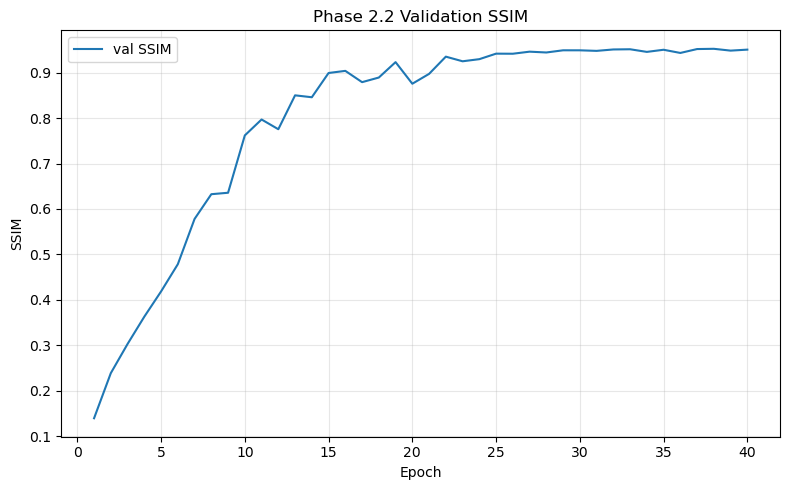

Saved:
  /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/phase2_2_total_loss_curve.png
  /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/phase2_2_loss_components_curve.png
  /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/phase2_2_psnr_curve.png
  /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/phase2_2_ssim_curve.png


In [12]:
history_df = pd.DataFrame(history)

epochs = history_df["epoch"].to_numpy()

# ==========================================================
# Total loss
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["train_loss"].to_numpy(),
    label="train total",
)

plt.plot(
    epochs,
    history_df["val_loss"].to_numpy(),
    label="val total",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 2.2 Memory-Preserving Total Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

loss_curve_path = (
    PHASE22_DIR
    / "phase2_2_total_loss_curve.png"
)

plt.savefig(loss_curve_path, dpi=150)
plt.show()

# ==========================================================
# Loss components
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_pixel_l1"].to_numpy(),
    label="pixel L1",
)

plt.plot(
    epochs,
    history_df["val_edge_l1"].to_numpy(),
    label="edge L1",
)

plt.plot(
    epochs,
    history_df["val_laplacian_l1"].to_numpy(),
    label="laplacian L1",
)

plt.plot(
    epochs,
    history_df["val_radial_l1"].to_numpy(),
    label="radial L1",
)

plt.xlabel("Epoch")
plt.ylabel("Component loss")
plt.title("Phase 2.2 Validation Loss Components")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

components_curve_path = (
    PHASE22_DIR
    / "phase2_2_loss_components_curve.png"
)

plt.savefig(components_curve_path, dpi=150)
plt.show()

# ==========================================================
# PSNR
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_psnr"].to_numpy(),
    label="val PSNR",
)

plt.xlabel("Epoch")
plt.ylabel("PSNR")
plt.title("Phase 2.2 Validation PSNR")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

psnr_curve_path = (
    PHASE22_DIR
    / "phase2_2_psnr_curve.png"
)

plt.savefig(psnr_curve_path, dpi=150)
plt.show()

# ==========================================================
# SSIM
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["val_ssim"].to_numpy(),
    label="val SSIM",
)

plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("Phase 2.2 Validation SSIM")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

ssim_curve_path = (
    PHASE22_DIR
    / "phase2_2_ssim_curve.png"
)

plt.savefig(ssim_curve_path, dpi=150)
plt.show()

print("Saved:")
print(" ", loss_curve_path)
print(" ", components_curve_path)
print(" ", psnr_curve_path)
print(" ", ssim_curve_path)

## 12. Load best model and test

In [17]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

test_metrics = evaluate(model, test_loader)

print("Test metrics:")
for key, value in test_metrics.items():
    print(f"  {key}: {value:.5f}")

test_metrics_path = PHASE22_DIR / "phase2_2_test_metrics.json"
with open(test_metrics_path, "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved:", test_metrics_path)

Test metrics:
  loss: 0.01205
  pixel_l1: 0.00850
  edge_l1: 0.00299
  laplacian_l1: 0.00654
  radial_l1: 0.00724
  flux_l1: 0.00290
  mse: 0.00038
  mae: 0.00850
  psnr: 34.39163
  ssim: 0.95493
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/phase2_2_test_metrics.json


## 13. Save prediction contact sheet

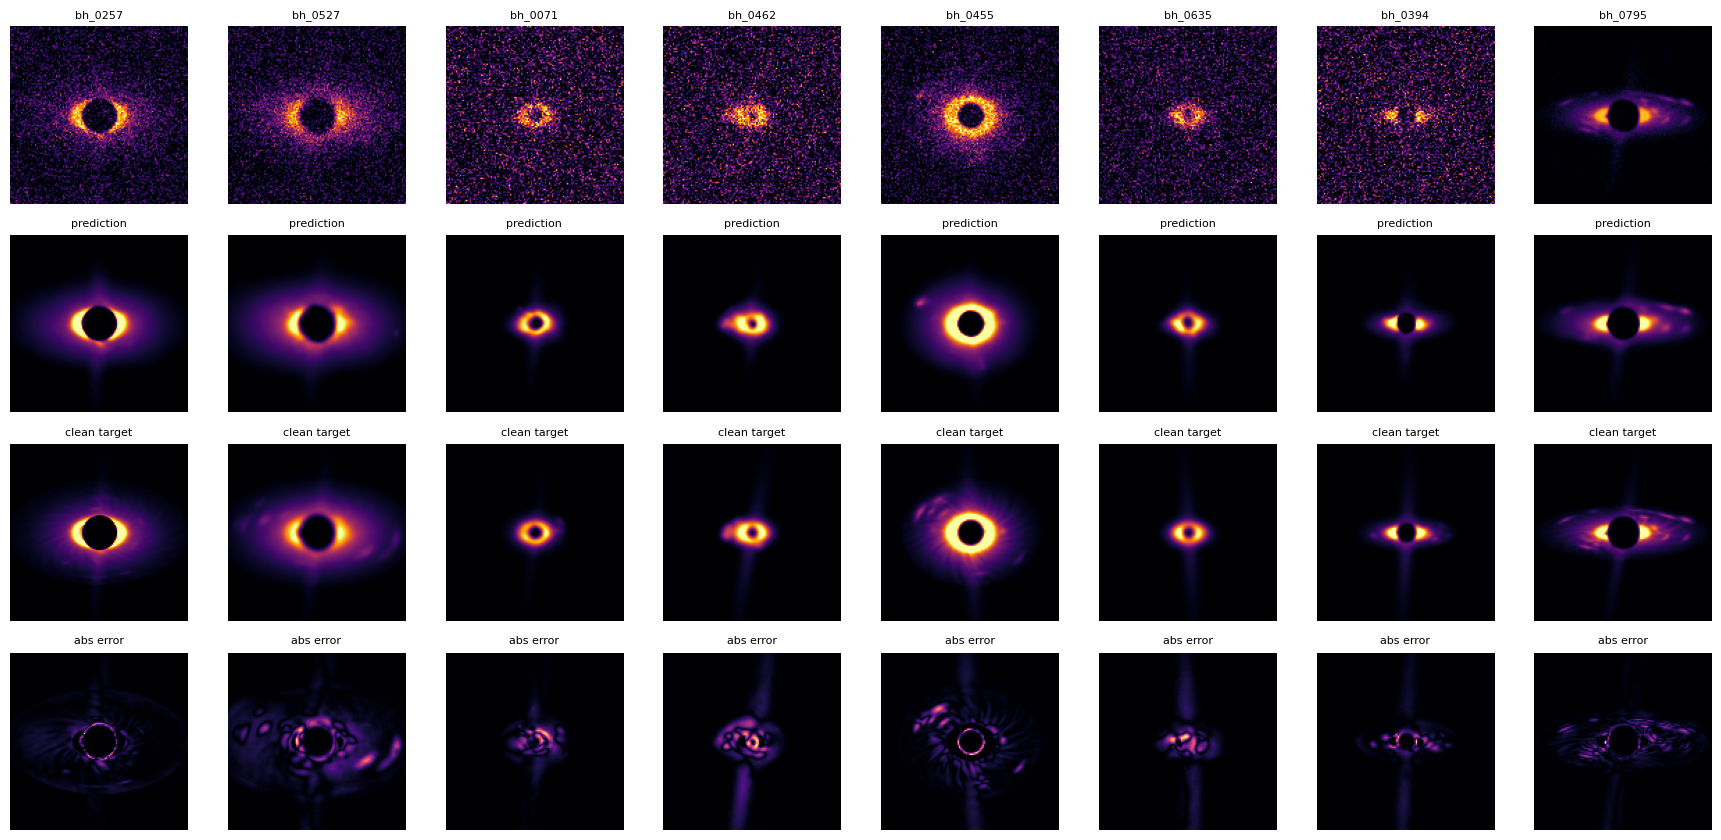

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/phase2_2_prediction_sheet.png


In [18]:
@torch.no_grad()
def make_prediction_sheet(model, loader, output_path, n=8):
    model.eval()
    noisy_batch, clean_batch, _, sample_ids = next(iter(loader))

    noisy_batch = noisy_batch[:n].to(DEVICE)
    clean_batch = clean_batch[:n].to(DEVICE)
    sample_ids = list(sample_ids[:n])

    pred_batch = model(noisy_batch)

    noisy_np = noisy_batch.cpu().numpy()
    clean_np = clean_batch.cpu().numpy()
    pred_np = pred_batch.cpu().numpy()

    n = noisy_np.shape[0]
    fig, axes = plt.subplots(4, n, figsize=(2.2 * n, 8.5))
    if n == 1:
        axes = axes.reshape(4, 1)

    for i in range(n):
        residual = np.abs(pred_np[i, 0] - clean_np[i, 0])

        axes[0, i].imshow(noisy_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[0, i].set_title(str(sample_ids[i]), fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(pred_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[1, i].set_title("prediction", fontsize=8)
        axes[1, i].axis("off")

        axes[2, i].imshow(clean_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[2, i].set_title("clean target", fontsize=8)
        axes[2, i].axis("off")

        axes[3, i].imshow(residual, cmap="magma", vmin=0, vmax=max(0.10, float(residual.max())))
        axes[3, i].set_title("abs error", fontsize=8)
        axes[3, i].axis("off")

    axes[0, 0].set_ylabel("Noisy", fontsize=10)
    axes[1, 0].set_ylabel("Pred", fontsize=10)
    axes[2, 0].set_ylabel("Clean", fontsize=10)
    axes[3, 0].set_ylabel("Error", fontsize=10)

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    return output_path

prediction_sheet_path = PHASE22_DIR / "phase2_2_prediction_sheet.png"
make_prediction_sheet(model, test_loader, prediction_sheet_path, n=8)
print("Saved:", prediction_sheet_path)

## 14. Save individual reconstructions

In [19]:
@torch.no_grad()
def save_individual_predictions(model, loader, output_dir, n=12):
    save_dir = output_dir / "sample_predictions_phase2_2"
    save_dir.mkdir(parents=True, exist_ok=True)

    model.eval()
    saved = 0

    for noisy, clean, history_summary, sample_ids in loader:
        noisy = noisy.to(DEVICE, non_blocking=True)
        pred = model(noisy)

        pred_np = pred.cpu().numpy()
        noisy_np = noisy.cpu().numpy()
        clean_np = clean.cpu().numpy()
        hist_np = history_summary.cpu().numpy()

        for i, sid in enumerate(sample_ids):
            if saved >= n:
                return save_dir

            for name, arr in [
                ("noisy", noisy_np[i, 0]),
                ("prediction", pred_np[i, 0]),
                ("clean", clean_np[i, 0]),
                ("abs_error", np.abs(pred_np[i, 0] - clean_np[i, 0])),
            ]:
                img = (np.clip(arr, 0.0, 1.0) * 255).astype(np.uint8)
                Image.fromarray(img).save(save_dir / f"{sid}_{name}.png")

            meta = {
                "sample_id": str(sid),
                "history_summary_vector": hist_np[i].astype(float).tolist(),
            }
            with open(save_dir / f"{sid}_metadata.json", "w") as f:
                json.dump(meta, f, indent=2)

            saved += 1

    return save_dir

save_dir = save_individual_predictions(model, test_loader, PHASE22_DIR, n=12)
print("Saved individual predictions to:", save_dir)

Saved individual predictions to: /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510/sample_predictions_phase2_2


## 15. Checkpoint sanity check for Phase 4 compatibility

This cell verifies that Phase 4 can load the saved model using the same `SmallUNet` class.

In [20]:
sanity_model = SmallUNet(in_channels=1, out_channels=1, base=32).to(DEVICE)
san_checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
sanity_model.load_state_dict(san_checkpoint["model_state_dict"])
sanity_model.eval()

with torch.no_grad():
    noisy, clean, _, sid = dataset[0]
    x = noisy.unsqueeze(0).to(DEVICE)
    y = sanity_model(x)
    features = sanity_model.encode(y)

print("Checkpoint compatibility passed.")
print("Sample:", sid)
print("Prediction shape:", y.shape)
print("Encoded feature shape:", features.shape)
print("Use this in Phase 4:")
print(f"UNET_CHECKPOINT = OUTPUT_DIR / '{BEST_MODEL_PATH.name}'")

Checkpoint compatibility passed.
Sample: bh_0001
Prediction shape: torch.Size([1, 1, 128, 128])
Encoded feature shape: torch.Size([1, 512, 8, 8])
Use this in Phase 4:
UNET_CHECKPOINT = OUTPUT_DIR / 'best_unet_memory_preserving_phase510.pt'


## 16. Phase 2.2 summary and next steps

In [21]:
summary_text = f"""
Phase 2.2 Summary — Memory-Preserving Reconstruction U-Net
==========================================================

Dataset:
  {DATASET_DIR}

Saved checkpoint:
  {BEST_MODEL_PATH}

Output directory:
  {PHASE22_DIR}

Best validation loss:
  {best_val_loss:.6f}

Test metrics:
  total loss = {test_metrics['loss']:.6f}
  pixel MAE  = {test_metrics['mae']:.6f}
  MSE        = {test_metrics['mse']:.6f}
  PSNR       = {test_metrics['psnr']:.4f}
  SSIM       = {test_metrics['ssim']:.4f}

Next required changes:

1. Phase 4 Cell 2:
   DATASET_DIR = PROJECT_ROOT / "data" / "dataset_phase5_8_morphology"
   PHASE4_DIR = OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase510"
   UNET_CHECKPOINT = OUTPUT_DIR / "best_unet_memory_preserving_phase510.pt"

2. Run Phase 4 three times:
   INPUT_MODE = "clean"
   INPUT_MODE = "noisy"
   INPUT_MODE = "reconstructed"

3. Phase 4.5 Cell 2:
   DATASET_DIR = PROJECT_ROOT / "data" / "dataset_phase5_8_morphology"
   PHASE4_DIR = OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase510"
   PHASE45_DIR = OUTPUT_DIR / "phase4_5_coupling_diagnosis_phase510"
   UNET_CHECKPOINT = OUTPUT_DIR / "best_unet_memory_preserving_phase510.pt"

4. Run Phase 4.5 at least for:
   INPUT_MODE = "reconstructed"

5. Then run Phase 5.9 with the same dataset and checkpoint.
"""

summary_path = PHASE22_DIR / "phase2_2_summary.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved summary:", summary_path)


Phase 2.2 Summary — Memory-Preserving Reconstruction U-Net

Dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_8_morphology

Saved checkpoint:
  /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase510.pt

Output directory:
  /home/marwa/files/phase1_blackhole_generator/outputs/phase2_2_memory_preserving_reconstruction_phase510

Best validation loss:
  0.011333

Test metrics:
  total loss = 0.012046
  pixel MAE  = 0.008497
  MSE        = 0.000375
  PSNR       = 34.3916
  SSIM       = 0.9549

Next required changes:

1. Phase 4 Cell 2:
   DATASET_DIR = PROJECT_ROOT / "data" / "dataset_phase5_8_morphology"
   PHASE4_DIR = OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase510"
   UNET_CHECKPOINT = OUTPUT_DIR / "best_unet_memory_preserving_phase510.pt"

2. Run Phase 4 three times:
   INPUT_MODE = "clean"
   INPUT_MODE = "noisy"
   INPUT_MODE = "reconstructed"

3. Phase 4.5 Cell 2:
   DATASET_DIR = PROJECT_ROOT / "data" / "da